# Spiking Diffusion: Toy Diffusion-Style Denoising on MNIST

This notebook implements and evaluates the **denoising component** of a toy diffusion model using **Spiking Neural Networks (SNNs)** and Poisson spike-inspired noise.

---

## 🎯 Objective

- Implement forward diffusion (corruption process)
- Train a spiking neural network to predict noise
- Evaluate denoising both visually and quantitatively

---

## ⚠️ Note

Full high-quality generation from pure noise is computationally expensive, especially for SNNs.  
Therefore, this notebook focuses on validating the **denoising objective**, which is the core learning principle of diffusion models.

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from snntorch import spikegen
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

from core.models import SpikingDenoiser
from core.diffusion import SpikingDiffusion

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [2]:
transform = transforms.ToTensor()
dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True)


100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:05<00:00, 1.69MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 54.1kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 750kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 4.04MB/s]


In [3]:
# Diffusion parameters
T = 50          # number of diffusion steps
num_steps = 20  # SNN simulation steps

diff = SpikingDiffusion(timesteps=T, device=device)
model = SpikingDenoiser().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 10


In [4]:
# Training: the denoiser learns to predict the noise added to the image

loss_history = []

for epoch in range(epochs):
    total_loss = 0
    pbar = tqdm(loader)

    for x, _ in pbar:
        x = x.view(-1, 784).to(device)

        # Sample random timestep for each image
        t = torch.randint(0, T, (x.size(0),), device=device)

        # Generate Poisson-like noise
        noise = diff.poisson_noise(torch.ones_like(x))

        # Create noisy image x_t using diffusion equation
        x_t = diff.q_sample(x, t, noise)

        # Convert noisy image to spikes
        spk = spikegen.rate(x_t, num_steps=num_steps)

        # Predict noise using spiking denoiser
        pred_noise = model(spk, t)

        # Diffusion loss: predict the noise
        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_description(f"Epoch {epoch+1} Loss {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)


Epoch 10 Loss 1.0073: 100%|██████████████████████████████████████████████████████████| 938/938 [02:48<00:00,  5.56it/s]


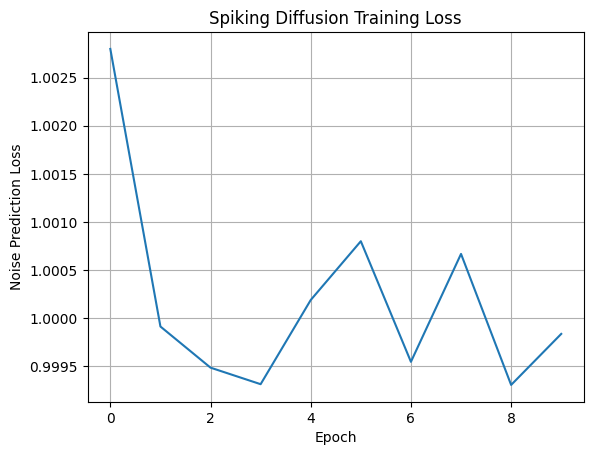

In [9]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Noise Prediction Loss")
plt.title("Spiking Diffusion Training Loss")
plt.grid(True)
plt.show()


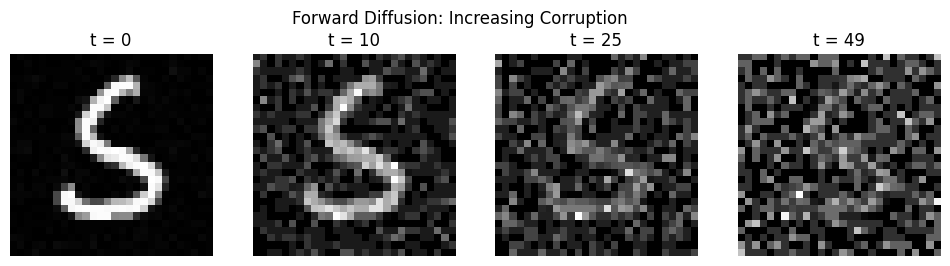

In [10]:
# Visualize how images get progressively corrupted by forward diffusion

x,_ = next(iter(loader))
x = x.view(-1,784).to(device)

steps = [0, 10, 25, 49]

plt.figure(figsize=(12,3))
for i, tval in enumerate(steps):
    t = torch.full((x.size(0),), tval, device=device)
    noise = diff.poisson_noise(torch.ones_like(x))
    x_t = diff.q_sample(x, t, noise)

    plt.subplot(1, len(steps), i+1)
    plt.imshow(x_t[0].cpu().view(28,28), cmap="gray")
    plt.title(f"t = {tval}")
    plt.axis("off")

plt.suptitle("Forward Diffusion: Increasing Corruption")
plt.show()


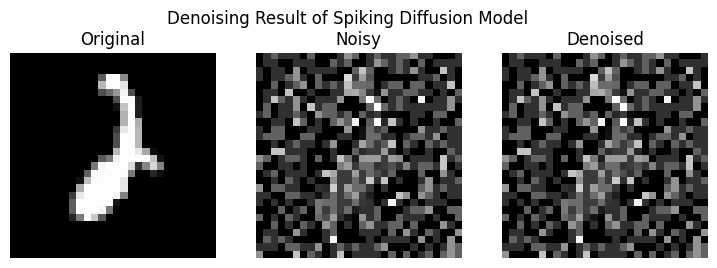

In [11]:
# Visualize denoising on a real MNIST image

model.eval()
with torch.no_grad():
    x,_ = next(iter(loader))
    x = x.view(-1,784).to(device)

    # Use maximum noise level
    t = torch.full((x.size(0),), T-1, device=device)

    noise = diff.poisson_noise(torch.ones_like(x))
    x_t = diff.q_sample(x, t, noise)

    # Denoise
    spk = spikegen.rate(x_t, num_steps=num_steps)
    pred_noise = model(spk, t)

    x0_pred = x_t - pred_noise

# Plot comparison
plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(x[0].cpu().view(28,28), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(x_t[0].cpu().view(28,28), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(x0_pred[0].cpu().view(28,28), cmap="gray")
plt.title("Denoised")
plt.axis("off")

plt.suptitle("Denoising Result of Spiking Diffusion Model")
plt.show()


In [12]:
# Quantitative comparison: Noisy vs Denoised

model.eval()
with torch.no_grad():
    x,_ = next(iter(loader))
    x = x.view(-1,784).to(device)

    t = torch.full((x.size(0),), T-1, device=device)

    noise = diff.poisson_noise(torch.ones_like(x))
    x_t = diff.q_sample(x, t, noise)

    spk = spikegen.rate(x_t, num_steps=num_steps)
    pred_noise = model(spk, t)

    x0_pred = x_t - pred_noise
    

    mse_noisy = F.mse_loss(x_t, x)
    mse_denoised = F.mse_loss(x0_pred, x)

print("MSE(Noisy vs Original):   ", mse_noisy.item())
print("MSE(Denoised vs Original):", mse_denoised.item())


MSE(Noisy vs Original):    0.7647603750228882
MSE(Denoised vs Original): 0.5617419481277466


## ✅ Conclusion

This notebook demonstrates that a spiking neural network can learn to **partially reverse diffusion-style corruption**.

Key observations:
- The model learns to predict injected noise using spike-based representations
- Denoised outputs are quantitatively closer to the original data compared to noisy inputs
- This validates the **denoising objective**, which is central to diffusion-based generative models

---

## 📊 Key Insight

Even without full convergence or high-quality generation, the reduction in reconstruction error (MSE) shows that the model is learning a meaningful reverse process.

---

## ⚠️ Limitation

Training diffusion models with spiking neural networks is computationally expensive, and results may remain noisy without extensive training.

---

## 🚀 Takeaway

This experiment provides a proof-of-concept that **diffusion-style denoising can be implemented using spiking neural networks**, opening the door for future work in neuromorphic generative modeling.